In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ============================================================
# LOAD CLEAN FEATURE SET FROM NOTEBOOK 02
# # No need to redo all the merging — start from clean data
# ============================================================
df_model = pd.read_csv('df_model.csv')

print("Shape:", df_model.shape)
print("\nColumns:", df_model.columns.tolist())
print("\nSample:")
print(df_model.head())

Shape: (433537, 12)

Columns: ['Win', 'kda_ratio', 'gold_per_min', 'dmg_per_min', 'cs_per_min', 'visionScore', 'objective_participation', 'Lane', 'RankName', 'GameDuration', 'SummonerFk', 'MatchFk']

Sample:
   Win  kda_ratio  gold_per_min  dmg_per_min  cs_per_min  visionScore  \
0    0        6.0    241.850371   163.278127    1.027984           67   
1    0        5.0    275.850860   252.992352    0.831740           88   
2    1        4.4    254.125214   164.922813    0.874786           97   
3    0        7.0    227.112172   135.143198    1.002387           60   
4    0        1.4    253.962264   144.665523    1.234991           55   

   objective_participation    Lane RankName  GameDuration  SummonerFk  \
0                        0  BOTTOM  Diamond          1751           1   
1                        0  BOTTOM  Diamond          2092           1   
2                        0  BOTTOM  Diamond          2332           1   
3                        0  BOTTOM  Diamond          1676    

In [3]:
# ============================================================
# STEP 1: SELECT CLUSTERING FEATURES
# Only use continuous behavioral features for clustering
# KMeans works on numbers only — no strings like Lane or RankName
# Exclude Win because we don't want the cluster to just
# separate winners from losers — want behavioral patterns
# Exclude SummonerFk, MatchFk as they are just ID columns
# ============================================================
cluster_features = [
    'kda_ratio',
    'gold_per_min',
    'dmg_per_min',
    'cs_per_min',
    'visionScore',
    'objective_participation'
]

X = df_model[cluster_features].copy()
print("Clustering input shape:", X.shape)
print("\nFeature stats:")
print(X.describe().round(2))

Clustering input shape: (433537, 6)

Feature stats:
       kda_ratio  gold_per_min  dmg_per_min  cs_per_min  visionScore  \
count  433537.00     433537.00    433537.00   433537.00    433537.00   
mean        3.45        399.65       711.11        4.44        29.72   
std         3.61         90.07       337.28        2.97        23.97   
min         0.00        136.51         0.00        0.00         0.00   
25%         1.25        332.15       455.52        1.11        14.00   
50%         2.25        394.20       669.56        5.45        22.00   
75%         4.17        459.11       913.89        7.01        36.00   
max        20.00        639.08      1725.02        9.40       120.00   

       objective_participation  
count                433537.00  
mean                      0.45  
std                       1.03  
min                       0.00  
25%                       0.00  
50%                       0.00  
75%                       0.00  
max                       9.00  


In [4]:
# ============================================================
# STEP 2: SCALE FEATURES
# StandardScaler transforms each feature to have mean=0
# and standard deviation=1
# This puts all features on equal footing so no single feature
# dominates the clustering just because of its scale
# e.g. gold_per_min (136-639) vs kda_ratio (0-20)
# would be unfair without scaling
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe for readability
X_scaled = pd.DataFrame(X_scaled, columns=cluster_features)

print("After scaling — feature stats:")
print(X_scaled.describe().round(2))

After scaling — feature stats:
       kda_ratio  gold_per_min  dmg_per_min  cs_per_min  visionScore  \
count  433537.00     433537.00    433537.00   433537.00    433537.00   
mean       -0.00          0.00        -0.00        0.00        -0.00   
std         1.00          1.00         1.00        1.00         1.00   
min        -0.96         -2.92        -2.11       -1.49        -1.24   
25%        -0.61         -0.75        -0.76       -1.12        -0.66   
50%        -0.33         -0.06        -0.12        0.34        -0.32   
75%         0.20          0.66         0.60        0.87         0.26   
max         4.59          2.66         3.01        1.67         3.77   

       objective_participation  
count                433537.00  
mean                     -0.00  
std                       1.00  
min                      -0.44  
25%                      -0.44  
50%                      -0.44  
75%                      -0.44  
max                       8.30  


k=2: inertia=221202
k=3: inertia=172746
k=4: inertia=137270
k=5: inertia=118831
k=6: inertia=103620
k=7: inertia=95435
k=8: inertia=88973
k=9: inertia=83299
k=10: inertia=78738


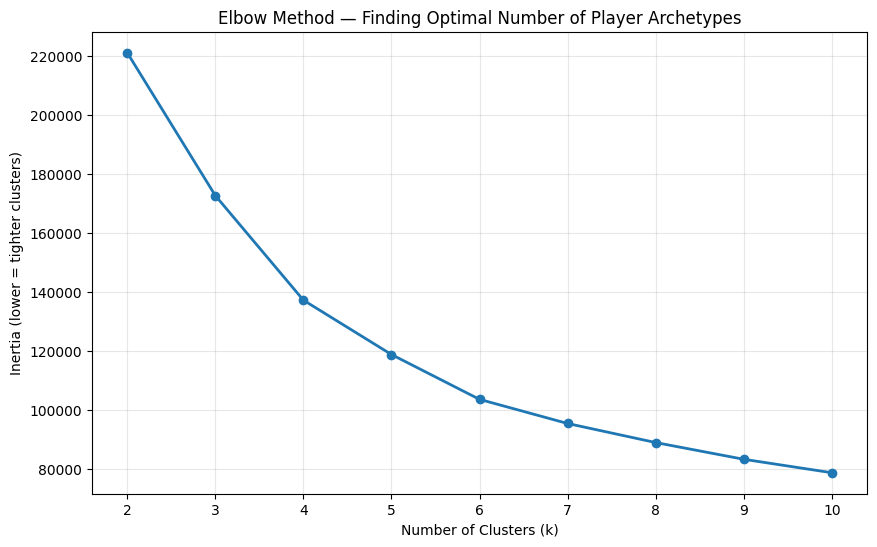

In [5]:
# ============================================================
# STEP 3: FIND OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)
# We don't know how many player archetypes exist
# The elbow method tries different cluster counts (k)
# and measures "inertia" (how tightly grouped the clusters are)
#
# As k increases, inertia always decreases — but at some point
# adding more clusters stops helping much. That bend in the
# curve (the "elbow") is the optimal k
#
# NOTE: We sample 50K rows here because running KMeans on all
# 433K rows for 10 different k values would be slow
# ============================================================

# Sample for speed — clustering tests don't need all rows
X_sample = X_scaled.sample(n=50000, random_state=42)

inertias = []
k_range = range(2, 11)  # test k from 2 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: inertia={kmeans.inertia_:.0f}")

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.title('Elbow Method — Finding Optimal Number of Player Archetypes')
plt.grid(True, alpha=0.3)
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ============================================================
# STEP 4: RUN FINAL KMEANS WITH k=4
# Based on the elbow method we pick 4 player archetypes
# We fit on the FULL dataset now (not the sample)
# random_state=42 makes results reproducible
# ============================================================
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_model['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(df_model['cluster'].value_counts().sort_index())

# ============================================================
# STEP 5: EXAMINE CLUSTER CHARACTERISTICS
# We look at the average feature values per cluster
# This tells us what behavioral pattern each cluster represents
# so we can name them meaningfully
# ============================================================
print("\nCluster behavioral profiles (mean values):")
cluster_profile = df_model.groupby('cluster')[cluster_features].mean().round(2)
print(cluster_profile)

Cluster sizes:
cluster
0    126625
1    177781
2     73995
3     55136
Name: count, dtype: int64

Cluster behavioral profiles (mean values):
         kda_ratio  gold_per_min  dmg_per_min  cs_per_min  visionScore  \
cluster                                                                  
0             4.87        488.02      1053.76        7.04        21.82   
1             1.60        358.80       566.87        5.02        18.04   
2             3.92        305.51       441.22        1.15        71.16   
3             5.50        454.73       751.43        0.96        29.96   

         objective_participation  
cluster                           
0                           0.17  
1                           0.11  
2                           0.07  
3                           2.74  


In [7]:
# ============================================================
# STEP 6: NAME THE CLUSTERS
# We map each cluster number to a meaningful archetype name
# based on the behavioral profiles we just examined
# This makes the analysis interpretable for stakeholders
# ============================================================
archetype_names = {
    0: 'The Carry',           # High damage, high farm, low vision
    1: 'The Struggler',       # Low impact across all metrics
    2: 'The Vision Support',  # Very high vision, low farm/gold
    3: 'The Playmaker'        # High KDA, high objective control
}

df_model['archetype'] = df_model['cluster'].map(archetype_names)

print("Archetype distribution:")
print(df_model['archetype'].value_counts())

# ============================================================
# STEP 7: ARCHETYPE WIN RATES
# The key business insight — do certain archetypes win more?
# This directly informs the matchmaking angle of our project
# ============================================================
print("\nWin rate by archetype:")
archetype_winrate = df_model.groupby('archetype')['Win'].mean().round(3).sort_values(ascending=False)
print(archetype_winrate)

Archetype distribution:
archetype
The Struggler         177781
The Carry             126625
The Vision Support     73995
The Playmaker          55136
Name: count, dtype: int64

Win rate by archetype:
archetype
The Playmaker         0.717
The Carry             0.696
The Vision Support    0.513
The Struggler         0.291
Name: Win, dtype: float64


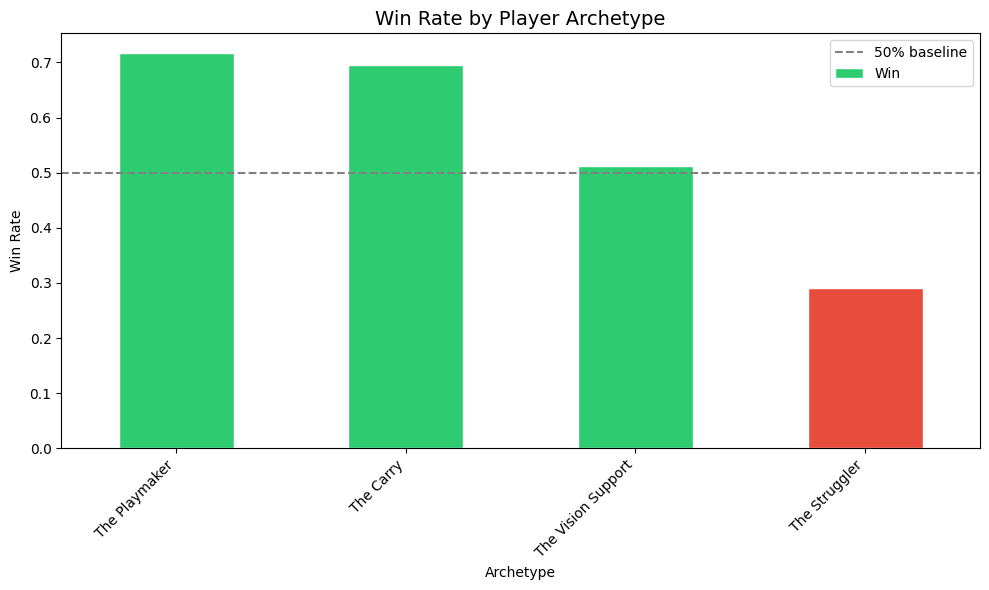

Saved df_clustered.csv with archetype labels


In [8]:
# ============================================================
# STEP 8: VISUALIZE ARCHETYPE WIN RATES
# A clean bar chart showing win rate by archetype
# This will go in your README and Part 05 business section
# ============================================================
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if x > 0.5 else '#e74c3c' for x in archetype_winrate.values]
archetype_winrate.plot(kind='bar', color=colors, edgecolor='white')
plt.axhline(y=0.5, color='gray', linestyle='--', label='50% baseline')
plt.title('Win Rate by Player Archetype', fontsize=14)
plt.ylabel('Win Rate')
plt.xlabel('Archetype')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('archetype_winrates.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STEP 9: SAVE CLUSTERED DATASET
# Save with cluster + archetype labels for use in notebook 04
# ============================================================
df_model.to_csv('df_clustered.csv', index=False)
print("Saved df_clustered.csv with archetype labels")